# Primary Model

## Purged Validation

- **Purpose:** Apply `purged_validation.py`'s `PurgedKFold` directly to the development partition.
- **Settings:** `cv=5` contiguous folds; `pct_embargo=0.01`; `random_state=42`; fixed chronological holdout.
- **Data:** Use development features, direction labels, sample weights, and event information intervals.
- **Decision:** Purge overlapping intervals, exclude holdout from every fold, and minimize weighted log loss with weighted F1 used only for exact ties.


In [1]:
from pathlib import Path

import joblib
from IPython import get_ipython

get_ipython().run_line_magic("matplotlib", "inline")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.base import clone
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)

PROJECT_ROOT = Path.cwd().resolve().parents[1]

from src.modeling.purged_validation import PurgedKFold
from src.modeling.feature_importance import (
    get_estimator_feature_importance,
)
from src.modeling.hyperparameter_tuning import (
    fit_classifier_with_hyperparameter_search,
)
from src.modeling.model_workflow import (
    build_candidate_classifiers,
    build_primary_model_frame,
    candidate_parameter_grids,
    generate_oof_predictions,
    get_primary_feature_columns,
    get_weighted_learning_curve,
    score_binary_predictions,
)

RANDOM_STATE = 42
CV_SPLITS = 5
PCT_EMBARGO = 0.01
TRAIN_SIZES = [0.20, 0.40, 0.60, 0.80, 1.00]
period = "2025-01-01_2025-12-31"
event_path = PROJECT_ROOT / f"data/research_data/events/aapl_model_events_{period}.parquet"
artifact_dir = PROJECT_ROOT / "data/model_artifact"
artifact_dir.mkdir(parents=True, exist_ok=True)

events = pd.read_parquet(event_path).sort_values("event_start", ignore_index=True)
development_starts = events.loc[
    events["partition"].eq("development"), "event_start"
]
holdout_starts = events.loc[
    events["partition"].eq("holdout"), "event_start"
]
development = build_primary_model_frame(events, development_starts)
holdout = build_primary_model_frame(events, holdout_starts)
feature_columns = get_primary_feature_columns(development)

X_development = development[feature_columns]
y_development = development["direction_label"].astype("int8")
w_development = development["sample_weight"].astype("float64")
t1_development = development["event_end"]
CLASS_LABELS = [-1, 1]
LOG_LOSS_COLUMN = "log_loss"
SELECTION_COLUMNS = ["log_loss", "f1"]
SELECTION_ASCENDING = [True, False]
LEARNING_SCORING = "neg_log_loss"
IMPORTANCE_SCORING = "neg_log_loss"

cv = PurgedKFold(CV_SPLITS, t1=t1_development, pct_embargo=PCT_EMBARGO)
fold_assignment = pd.Series(pd.NA, index=X_development.index, dtype="Int64", name="cv_fold")
fold_rows = []
for fold, (train, test) in enumerate(cv.split(X_development)):
    fold_assignment.iloc[test] = fold
    fold_rows.append({
        "fold": fold,
        "train_events": len(train),
        "test_events": len(test),
        "test_start": t1_development.index[test].min(),
        "test_end": t1_development.iloc[test].max(),
    })

split_manifest = events[[
    "event_start", "event_end", "partition", "holdout_boundary"
]].merge(
    fold_assignment.rename_axis("event_start").reset_index(),
    on="event_start",
    how="left",
    validate="one_to_one",
)
split_manifest.to_parquet(artifact_dir / "split_manifest.parquet", index=False)
display(pd.DataFrame(fold_rows).set_index("fold"))
display(pd.Series({
    "development_events": len(development),
    "holdout_events": len(holdout),
    "features": len(feature_columns),
}, name="value").to_frame())


,train_events,test_events,test_start,test_end
fold,,,,
0,138,36,2025-01-13 14:30:01.329809+00:00,2025-03-20 14:01:02.091518+00:00
1,139,35,2025-03-20 16:08:22.001507+00:00,2025-05-01 19:46:02.785927+00:00
2,131,35,2025-05-02 13:30:00.196246+00:00,2025-06-10 13:32:16.641303+00:00
3,137,35,2025-06-09 17:19:58.366451+00:00,2025-08-07 13:31:08.635357+00:00
4,141,35,2025-08-07 17:17:15.020297+00:00,2025-10-15 17:47:53.217196+00:00


,value
development_events,176
holdout_events,22
features,53


## Ensemble Methods

- **Purpose:** Compare the boosting, bagging, and random-forest factories from `ensemble_methods.py`.
- **Settings:** `boosting_stages=100`; `bagging_estimators=120`; `rf_estimators=120`; `random_state=42`; `n_jobs=1`.
- **Data:** Generate comparable purged OOF predictions for all three candidates from the development partition.
- **Decision:** Rank candidates by minimum weighted log loss and use weighted F1 only for exact ties.


In [2]:
candidates = build_candidate_classifiers(
    random_state=RANDOM_STATE,
    n_jobs=1,
)

candidate_oof = {}
comparison_rows = []
for name, estimator in candidates.items():
    predictions = generate_oof_predictions(
        estimator,
        X_development,
        y_development,
        w_development,
        cv,
        positive_label=1,
    )
    candidate_oof[name] = predictions
    scores = score_binary_predictions(
        y_development,
        predictions["prediction"],
        predictions["probability"],
        w_development,
        class_labels=CLASS_LABELS,
        positive_label=1,
    )
    comparison_rows.append({
        "candidate": name,
        LOG_LOSS_COLUMN: scores["log_loss"],
        "f1": scores["f1"],
    })

comparison = pd.DataFrame(comparison_rows).set_index("candidate")
ranked_comparison = comparison.sort_values(SELECTION_COLUMNS, ascending=SELECTION_ASCENDING)
selected_name = ranked_comparison.index[0]
selected_estimator = candidates[selected_name]
display(comparison.rename(index=lambda name: name.replace("_", " ").title()))
print(f"Selected baseline family: {selected_name}")


/Users/kwonjunhyuk9/Documents/financial-machine-learning/.venv/lib/python3.11/site-packages/sklearn/ensemble/_bagging.py:919: UserWarning: Some inputs do not have OOB scores. This probably means too few estimators were used to compute any reliable oob estimates.
  warn(
/Users/kwonjunhyuk9/Documents/financial-machine-learning/.venv/lib/python3.11/site-packages/sklearn/ensemble/_bagging.py:925: RuntimeWarning: invalid value encountered in divide
  oob_decision_function = predictions / predictions.sum(axis=1)[:, np.newaxis]
/Users/kwonjunhyuk9/Documents/financial-machine-learning/.venv/lib/python3.11/site-packages/sklearn/ensemble/_bagging.py:919: UserWarning: Some inputs do not have OOB scores. This probably means too few estimators were used to compute any reliable oob estimates.
  warn(
/Users/kwonjunhyuk9/Documents/financial-machine-learning/.venv/lib/python3.11/site-packages/sklearn/ensemble/_bagging.py:925: RuntimeWarning: invalid value encountered in divide
  oob_decision_function

/Users/kwonjunhyuk9/Documents/financial-machine-learning/.venv/lib/python3.11/site-packages/sklearn/ensemble/_bagging.py:919: UserWarning: Some inputs do not have OOB scores. This probably means too few estimators were used to compute any reliable oob estimates.
  warn(
/Users/kwonjunhyuk9/Documents/financial-machine-learning/.venv/lib/python3.11/site-packages/sklearn/ensemble/_bagging.py:925: RuntimeWarning: invalid value encountered in divide
  oob_decision_function = predictions / predictions.sum(axis=1)[:, np.newaxis]
/Users/kwonjunhyuk9/Documents/financial-machine-learning/.venv/lib/python3.11/site-packages/sklearn/ensemble/_bagging.py:919: UserWarning: Some inputs do not have OOB scores. This probably means too few estimators were used to compute any reliable oob estimates.
  warn(
/Users/kwonjunhyuk9/Documents/financial-machine-learning/.venv/lib/python3.11/site-packages/sklearn/ensemble/_bagging.py:925: RuntimeWarning: invalid value encountered in divide
  oob_decision_function

,log_loss,f1
candidate,,
Boosting,0.719688,0.433647
Bagging,0.754490,0.429163
Random Forest,0.718619,0.562775


Selected baseline family: random_forest


## Ensemble Methods Learning Curves

- **Purpose:** Use `get_weighted_learning_curve` to compare how the three baseline candidates learn across purged folds.
- **Settings:** `train_sizes=(0.20, 0.40, 0.60, 0.80, 1.00)`; `cv=5`; error is weighted log loss with mean and standard error.
- **Data:** Build learning curves from development folds only.
- **Decision:** Interpret the train-validation gap as a diagnostic rather than a model-selection result.


/Users/kwonjunhyuk9/Documents/financial-machine-learning/.venv/lib/python3.11/site-packages/sklearn/ensemble/_bagging.py:919: UserWarning: Some inputs do not have OOB scores. This probably means too few estimators were used to compute any reliable oob estimates.
  warn(
/Users/kwonjunhyuk9/Documents/financial-machine-learning/.venv/lib/python3.11/site-packages/sklearn/ensemble/_bagging.py:925: RuntimeWarning: invalid value encountered in divide
  oob_decision_function = predictions / predictions.sum(axis=1)[:, np.newaxis]
/Users/kwonjunhyuk9/Documents/financial-machine-learning/.venv/lib/python3.11/site-packages/sklearn/ensemble/_bagging.py:919: UserWarning: Some inputs do not have OOB scores. This probably means too few estimators were used to compute any reliable oob estimates.
  warn(
/Users/kwonjunhyuk9/Documents/financial-machine-learning/.venv/lib/python3.11/site-packages/sklearn/ensemble/_bagging.py:925: RuntimeWarning: invalid value encountered in divide
  oob_decision_function

/Users/kwonjunhyuk9/Documents/financial-machine-learning/.venv/lib/python3.11/site-packages/sklearn/ensemble/_bagging.py:919: UserWarning: Some inputs do not have OOB scores. This probably means too few estimators were used to compute any reliable oob estimates.
  warn(
/Users/kwonjunhyuk9/Documents/financial-machine-learning/.venv/lib/python3.11/site-packages/sklearn/ensemble/_bagging.py:925: RuntimeWarning: invalid value encountered in divide
  oob_decision_function = predictions / predictions.sum(axis=1)[:, np.newaxis]


/Users/kwonjunhyuk9/Documents/financial-machine-learning/.venv/lib/python3.11/site-packages/sklearn/ensemble/_bagging.py:919: UserWarning: Some inputs do not have OOB scores. This probably means too few estimators were used to compute any reliable oob estimates.
  warn(
/Users/kwonjunhyuk9/Documents/financial-machine-learning/.venv/lib/python3.11/site-packages/sklearn/ensemble/_bagging.py:925: RuntimeWarning: invalid value encountered in divide
  oob_decision_function = predictions / predictions.sum(axis=1)[:, np.newaxis]


/Users/kwonjunhyuk9/Documents/financial-machine-learning/.venv/lib/python3.11/site-packages/sklearn/ensemble/_bagging.py:919: UserWarning: Some inputs do not have OOB scores. This probably means too few estimators were used to compute any reliable oob estimates.
  warn(
/Users/kwonjunhyuk9/Documents/financial-machine-learning/.venv/lib/python3.11/site-packages/sklearn/ensemble/_bagging.py:925: RuntimeWarning: invalid value encountered in divide
  oob_decision_function = predictions / predictions.sum(axis=1)[:, np.newaxis]


/Users/kwonjunhyuk9/Documents/financial-machine-learning/.venv/lib/python3.11/site-packages/sklearn/ensemble/_bagging.py:919: UserWarning: Some inputs do not have OOB scores. This probably means too few estimators were used to compute any reliable oob estimates.
  warn(
/Users/kwonjunhyuk9/Documents/financial-machine-learning/.venv/lib/python3.11/site-packages/sklearn/ensemble/_bagging.py:925: RuntimeWarning: invalid value encountered in divide
  oob_decision_function = predictions / predictions.sum(axis=1)[:, np.newaxis]
/Users/kwonjunhyuk9/Documents/financial-machine-learning/.venv/lib/python3.11/site-packages/sklearn/ensemble/_bagging.py:919: UserWarning: Some inputs do not have OOB scores. This probably means too few estimators were used to compute any reliable oob estimates.
  warn(
/Users/kwonjunhyuk9/Documents/financial-machine-learning/.venv/lib/python3.11/site-packages/sklearn/ensemble/_bagging.py:925: RuntimeWarning: invalid value encountered in divide
  oob_decision_function

/Users/kwonjunhyuk9/Documents/financial-machine-learning/.venv/lib/python3.11/site-packages/sklearn/ensemble/_bagging.py:919: UserWarning: Some inputs do not have OOB scores. This probably means too few estimators were used to compute any reliable oob estimates.
  warn(
/Users/kwonjunhyuk9/Documents/financial-machine-learning/.venv/lib/python3.11/site-packages/sklearn/ensemble/_bagging.py:925: RuntimeWarning: invalid value encountered in divide
  oob_decision_function = predictions / predictions.sum(axis=1)[:, np.newaxis]
/Users/kwonjunhyuk9/Documents/financial-machine-learning/.venv/lib/python3.11/site-packages/sklearn/ensemble/_bagging.py:919: UserWarning: Some inputs do not have OOB scores. This probably means too few estimators were used to compute any reliable oob estimates.
  warn(
/Users/kwonjunhyuk9/Documents/financial-machine-learning/.venv/lib/python3.11/site-packages/sklearn/ensemble/_bagging.py:925: RuntimeWarning: invalid value encountered in divide
  oob_decision_function

/Users/kwonjunhyuk9/Documents/financial-machine-learning/.venv/lib/python3.11/site-packages/sklearn/ensemble/_bagging.py:919: UserWarning: Some inputs do not have OOB scores. This probably means too few estimators were used to compute any reliable oob estimates.
  warn(
/Users/kwonjunhyuk9/Documents/financial-machine-learning/.venv/lib/python3.11/site-packages/sklearn/ensemble/_bagging.py:925: RuntimeWarning: invalid value encountered in divide
  oob_decision_function = predictions / predictions.sum(axis=1)[:, np.newaxis]
/Users/kwonjunhyuk9/Documents/financial-machine-learning/.venv/lib/python3.11/site-packages/sklearn/ensemble/_bagging.py:919: UserWarning: Some inputs do not have OOB scores. This probably means too few estimators were used to compute any reliable oob estimates.
  warn(
/Users/kwonjunhyuk9/Documents/financial-machine-learning/.venv/lib/python3.11/site-packages/sklearn/ensemble/_bagging.py:925: RuntimeWarning: invalid value encountered in divide
  oob_decision_function

/Users/kwonjunhyuk9/Documents/financial-machine-learning/.venv/lib/python3.11/site-packages/sklearn/ensemble/_bagging.py:919: UserWarning: Some inputs do not have OOB scores. This probably means too few estimators were used to compute any reliable oob estimates.
  warn(
/Users/kwonjunhyuk9/Documents/financial-machine-learning/.venv/lib/python3.11/site-packages/sklearn/ensemble/_bagging.py:925: RuntimeWarning: invalid value encountered in divide
  oob_decision_function = predictions / predictions.sum(axis=1)[:, np.newaxis]
/Users/kwonjunhyuk9/Documents/financial-machine-learning/.venv/lib/python3.11/site-packages/sklearn/ensemble/_bagging.py:919: UserWarning: Some inputs do not have OOB scores. This probably means too few estimators were used to compute any reliable oob estimates.
  warn(
/Users/kwonjunhyuk9/Documents/financial-machine-learning/.venv/lib/python3.11/site-packages/sklearn/ensemble/_bagging.py:925: RuntimeWarning: invalid value encountered in divide
  oob_decision_function

/Users/kwonjunhyuk9/Documents/financial-machine-learning/.venv/lib/python3.11/site-packages/sklearn/ensemble/_bagging.py:919: UserWarning: Some inputs do not have OOB scores. This probably means too few estimators were used to compute any reliable oob estimates.
  warn(
/Users/kwonjunhyuk9/Documents/financial-machine-learning/.venv/lib/python3.11/site-packages/sklearn/ensemble/_bagging.py:925: RuntimeWarning: invalid value encountered in divide
  oob_decision_function = predictions / predictions.sum(axis=1)[:, np.newaxis]


/Users/kwonjunhyuk9/Documents/financial-machine-learning/.venv/lib/python3.11/site-packages/sklearn/ensemble/_bagging.py:919: UserWarning: Some inputs do not have OOB scores. This probably means too few estimators were used to compute any reliable oob estimates.
  warn(
/Users/kwonjunhyuk9/Documents/financial-machine-learning/.venv/lib/python3.11/site-packages/sklearn/ensemble/_bagging.py:925: RuntimeWarning: invalid value encountered in divide
  oob_decision_function = predictions / predictions.sum(axis=1)[:, np.newaxis]


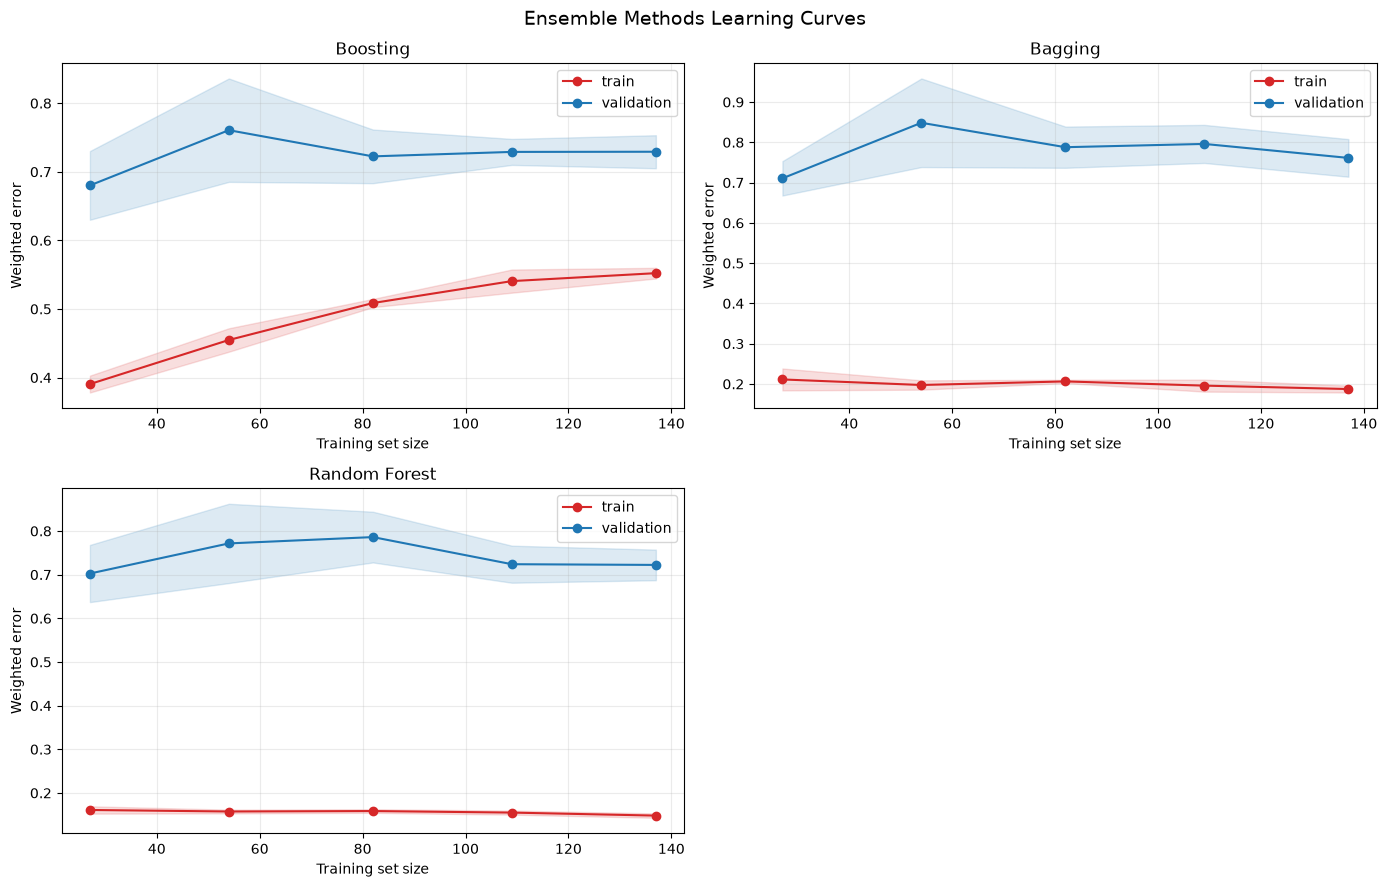

In [3]:
def plot_learning_curves(estimators, heading):
    results = {}
    model_count = len(estimators)
    grid_size = 1 if model_count == 1 else 2
    figure_size = (7, 5.5) if model_count == 1 else (14, 9)
    fig, axes = plt.subplots(
        grid_size,
        grid_size,
        figsize=figure_size,
        sharex=False,
        sharey=False,
    )
    axes = np.atleast_1d(axes).ravel()
    for axis, (name, estimator) in zip(axes, estimators.items()):
        curve = get_weighted_learning_curve(
            estimator,
            X_development,
            y_development,
            w_development,
            cv,
            train_sizes=TRAIN_SIZES,
            class_labels=CLASS_LABELS,
            positive_label=1,
            scoring=LEARNING_SCORING,
            random_state=RANDOM_STATE,
        )
        results[name] = curve
        x = curve["train_size"].to_numpy()
        for split, color in [("train", "tab:red"), ("validation", "tab:blue")]:
            mean = curve[f"{split}_error_mean"].to_numpy()
            error = curve[f"{split}_error_std"].fillna(0.0).to_numpy()
            axis.plot(x, mean, marker="o", color=color, label=split)
            axis.fill_between(x, mean - error, mean + error, color=color, alpha=0.15)
        axis.set_title(name.replace("_", " ").title())
        axis.set_xlabel("Training set size")
        axis.set_ylabel("Weighted error")
        axis.grid(alpha=0.25)
        axis.legend()
    for unused_axis in axes[model_count:]:
        unused_axis.remove()
    fig.suptitle(heading, fontsize=14)
    fig.tight_layout()
    plt.show()
    return results


ensemble_learning_curves = plot_learning_curves(
    candidates,
    "Ensemble Methods Learning Curves",
)


## Ensemble Methods Feature Importance

- **Purpose:** Apply estimator-aware MDI, MDA, and SFI to the selected baseline family.
- **Settings:** `cv=5`; `pct_embargo=0.01`; `random_state=42`; `top_k=15`; MDA and SFI use weighted negative log loss.
- **Data:** Calculate and preserve importance results for all 53 development features.
- **Decision:** Treat importance as a diagnostic rather than causal evidence or a new selection step.


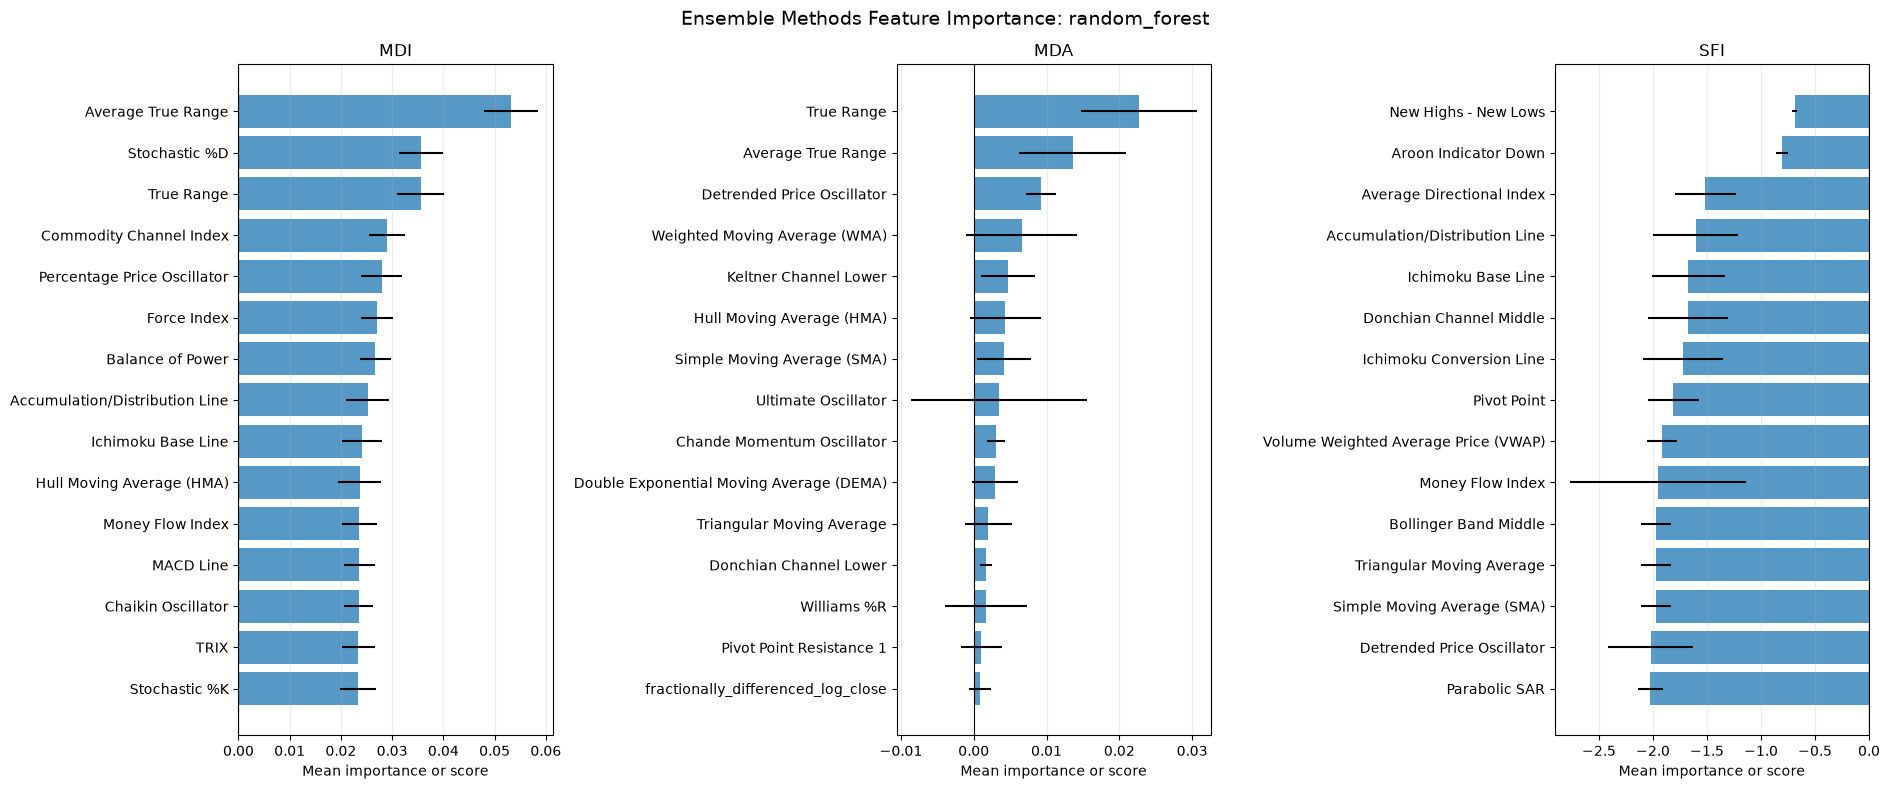

,oos_score
MDI,-0.72233
MDA,-0.72233
SFI,-0.72233


In [4]:
def compute_stage_importance(estimator):
    results = {}
    scores = {}
    for method in ["MDI", "MDA", "SFI"]:
        importance, oos = get_estimator_feature_importance(
            estimator,
            X_development,
            y_development,
            w_development,
            t1_development,
            method=method,
            scoring=IMPORTANCE_SCORING,
            cv=CV_SPLITS,
            pct_embargo=PCT_EMBARGO,
            random_state=RANDOM_STATE,
        )
        results[method] = importance
        scores[method] = oos
    return results, pd.Series(scores, name="oos_score")


def plot_feature_importance(results, heading):
    fig, axes = plt.subplots(1, 3, figsize=(19, 8))
    for axis, method in zip(axes, ["MDI", "MDA", "SFI"]):
        importance = results[method].nlargest(15, "mean").sort_values("mean")
        axis.barh(
            importance.index,
            importance["mean"],
            xerr=importance["std"].fillna(0.0),
            alpha=0.75,
            color="tab:blue",
        )
        axis.axvline(0.0, color="black", linewidth=0.8)
        axis.set_title(method)
        axis.set_xlabel("Mean importance or score")
        axis.grid(axis="x", alpha=0.25)
    fig.suptitle(heading, fontsize=14)
    fig.tight_layout()
    plt.show()


ensemble_importance_results, ensemble_importance_scores = compute_stage_importance(
    selected_estimator
)
plot_feature_importance(
    ensemble_importance_results,
    f"Ensemble Methods Feature Importance: {selected_name}",
)
display(ensemble_importance_scores.to_frame())


## Ensemble Methods Model Evaluation

- **Purpose:** Compare baseline weighted accuracy, precision, recall, F1, log loss, confusion matrices, PR curves, and ROC curves.
- **Settings:** Metric order is accuracy, precision, recall, F1, then weighted log loss; `positive_label=1`; weighted confusion matrices, PR, ROC, AP, and ROC AUC.
- **Data:** Evaluate the development OOF predictions for all three candidates.
- **Decision:** Do not use holdout curves to adjust thresholds.


,accuracy,precision,recall,f1,log_loss
model,,,,,
Boosting,0.461988,0.420949,0.447134,0.433647,0.719688
Bagging,0.461934,0.419685,0.439078,0.429163,0.754490
Random Forest,0.579238,0.539755,0.587847,0.562775,0.718619


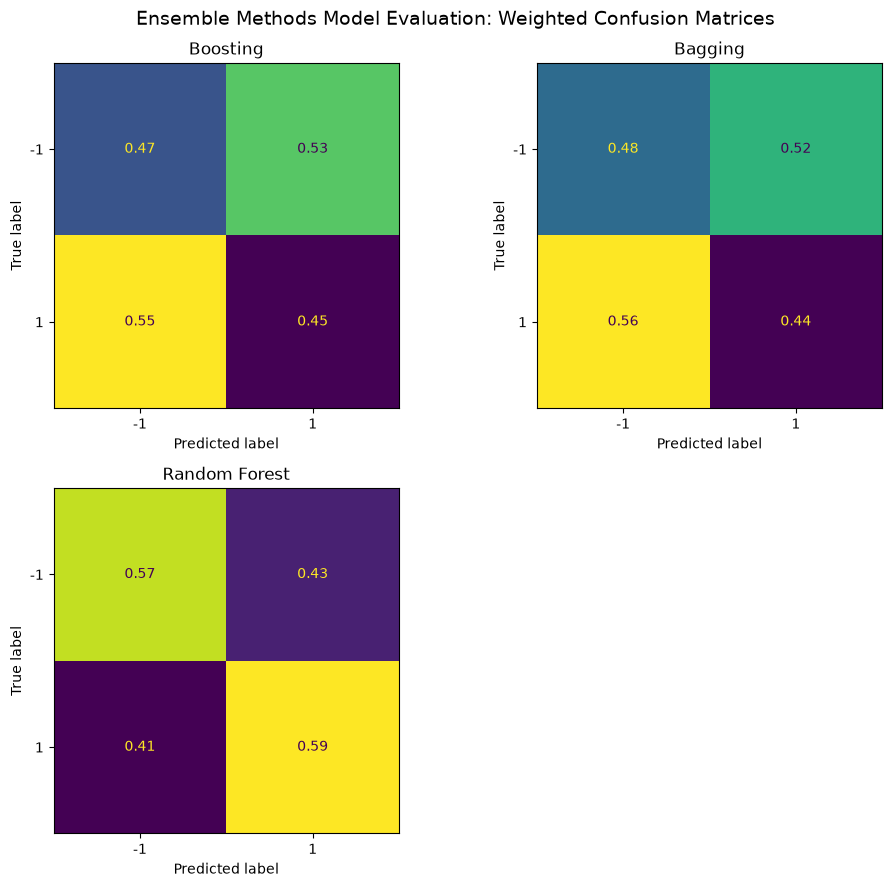

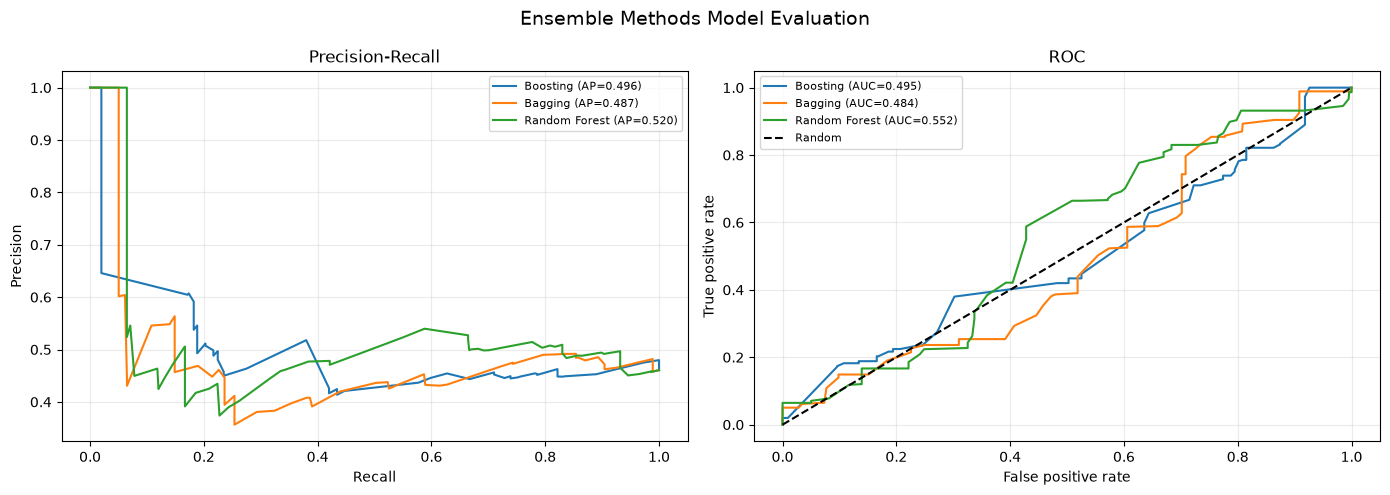

In [5]:
def plot_model_evaluation(predictions_by_model, observed, weights, heading):
    metric_rows = []
    for name, predictions in predictions_by_model.items():
        scores = score_binary_predictions(
            observed,
            predictions["prediction"],
            predictions["probability"],
            weights,
            class_labels=CLASS_LABELS,
            positive_label=1,
        )
        metric_rows.append({
            "model": name,
            "accuracy": scores["accuracy"],
            "precision": scores["precision"],
            "recall": scores["recall"],
            "f1": scores["f1"],
            LOG_LOSS_COLUMN: scores["log_loss"],
        })
    display(pd.DataFrame(metric_rows).set_index("model").rename(index=lambda name: name.replace("_", " ").title()))

    model_count = len(predictions_by_model)
    grid_size = 1 if model_count == 1 else 2
    figure_size = (7, 5.5) if model_count == 1 else (10, 9)
    fig, axes = plt.subplots(grid_size, grid_size, figsize=figure_size)
    axes = np.atleast_1d(axes).ravel()
    for axis, (name, predictions) in zip(axes, predictions_by_model.items()):
        matrix = confusion_matrix(
            observed,
            predictions["prediction"],
            labels=CLASS_LABELS,
            sample_weight=weights,
            normalize="true",
        )
        ConfusionMatrixDisplay(matrix, display_labels=CLASS_LABELS).plot(
            ax=axis,
            colorbar=False,
            values_format=".2f",
        )
        axis.set_title(name.replace("_", " ").title())
    for unused_axis in axes[model_count:]:
        unused_axis.remove()
    fig.suptitle(f"{heading}: Weighted Confusion Matrices", fontsize=14)
    fig.tight_layout()
    plt.show()

    fig, (pr_axis, roc_axis) = plt.subplots(1, 2, figsize=(14, 5))
    for name, predictions in predictions_by_model.items():
        probability = predictions["probability"]
        precision, recall, _ = precision_recall_curve(
            observed,
            probability,
            pos_label=1,
            sample_weight=weights,
        )
        average_precision = average_precision_score(
            observed,
            probability,
            pos_label=1,
            sample_weight=weights,
        )
        pr_axis.plot(recall, precision, label=f"{name.replace('_', ' ').title()} (AP={average_precision:.3f})")

        false_positive_rate, true_positive_rate, _ = roc_curve(
            observed,
            probability,
            pos_label=1,
            sample_weight=weights,
        )
        auc = roc_auc_score(observed, probability, sample_weight=weights)
        roc_axis.plot(
            false_positive_rate,
            true_positive_rate,
            label=f"{name.replace('_', ' ').title()} (AUC={auc:.3f})",
        )

    pr_axis.set(xlabel="Recall", ylabel="Precision", title="Precision-Recall")
    pr_axis.grid(alpha=0.25)
    pr_axis.legend(fontsize=8)
    roc_axis.plot([0, 1], [0, 1], "k--", label="Random")
    roc_axis.set(xlabel="False positive rate", ylabel="True positive rate", title="ROC")
    roc_axis.grid(alpha=0.25)
    roc_axis.legend(fontsize=8)
    fig.suptitle(heading, fontsize=14)
    fig.tight_layout()
    plt.show()


plot_model_evaluation(
    candidate_oof,
    y_development,
    w_development,
    "Ensemble Methods Model Evaluation",
)


## Hyperparameter Tuning

- **Purpose:** Use `fit_classifier_with_hyperparameter_search` to tune only the family selected by the baseline comparison.
- **Settings:** `cv=5`; `pct_embargo=0.01`; selected-family grids cover bagging `max_samples`, RF `max_features`, or boosting `learning_rate` at three fixed values.
- **Data:** Apply sample weights within purged development folds for the selected family.
- **Decision:** Minimize weighted log loss, use weighted F1 for ties, and accept no holdout feedback.


In [6]:
def to_grid_search_space(configurations):
    grid = {}
    for configuration in configurations:
        for parameter, value in configuration.items():
            grid.setdefault(parameter, []).append(value)
    return grid


parameter_grids = candidate_parameter_grids()
parameter_grid = to_grid_search_space(parameter_grids[selected_name])
fitted = fit_classifier_with_hyperparameter_search(
    X_development,
    y_development,
    t1_development,
    selected_estimator,
    parameter_grid,
    cv=CV_SPLITS,
    n_jobs=1,
    pct_embargo=PCT_EMBARGO,
    sample_weight=w_development.to_numpy(),
)
final_name = selected_name
final_configuration = {
    parameter: fitted.get_params()[parameter]
    for parameter in parameter_grid
}
final_estimator = clone(fitted)
final_oof = generate_oof_predictions(
    final_estimator,
    X_development,
    y_development,
    w_development,
    cv,
    positive_label=1,
)
scores = score_binary_predictions(
    y_development,
    final_oof["prediction"],
    final_oof["probability"],
    w_development,
    class_labels=CLASS_LABELS,
    positive_label=1,
)
tuning_columns = [
    "candidate",
    "configuration",
    "model__max_samples",
    "model__max_features",
    "model__learning_rate",
    LOG_LOSS_COLUMN,
    "f1",
]
tuning = pd.DataFrame([{
    "candidate": final_name,
    "configuration": repr(final_configuration),
    **final_configuration,
    LOG_LOSS_COLUMN: scores["log_loss"],
    "f1": scores["f1"],
}]).reindex(columns=tuning_columns)
tuned_estimators = {f"{final_name}_tuned": final_estimator}
display(tuning)
print(f"Selected tuned family: {final_name}")


/Users/kwonjunhyuk9/Documents/financial-machine-learning/.venv/lib/python3.11/site-packages/sklearn/model_selection/_search.py:921: UserWarning: The scoring <function fit_classifier_with_hyperparameter_search.<locals>.weighted_scorer at 0x12195df80> does not support sample_weight, which may lead to statistically incorrect results when fitting GridSearchCV(cv=PurgedKFold(n_splits=5, pct_embargo=0.01,
      t1=event_start
2025-01-13 14:30:01.329809+00:00   2025-01-13 14:34:17.401727+00:00
2025-01-16 14:30:01.488226+00:00   2025-01-16 14:34:43.996829+00:00
2025-01-17 14:30:01.792073+00:00   2025-01-17 14:39:01.069235+00:00
2025-01-17 17:20:53.298606+00:00   2025-01-21 14:30:00.854179+00:00
2025-01-21 14...84+00:00   2025-10-1...
Name: event_end, Length: 176, dtype: datetime64[us, UTC]),
             estimator=MyPipeline(steps=[('model',
                                          RandomForestClassifier(class_weight='balanced_subsample',
                                                      

,candidate,configuration,model__max_samples,model__max_features,model__learning_rate,log_loss,f1
0,random_forest,{'model__max_features': 'sqrt'},NaN,sqrt,NaN,0.718619,0.562775


Selected tuned family: random_forest


## Hyperparameter Tuning Learning Curves

- **Purpose:** Diagnose the selected tuned estimator with the same weighted learning-curve helper.
- **Settings:** `train_sizes=(0.20, 0.40, 0.60, 0.80, 1.00)`; `cv=5`; `pct_embargo=0.01`; error is weighted log loss.
- **Data:** Build the tuned estimator's learning curve from development folds only.
- **Decision:** Do not revise the model or grid from holdout learning behavior.


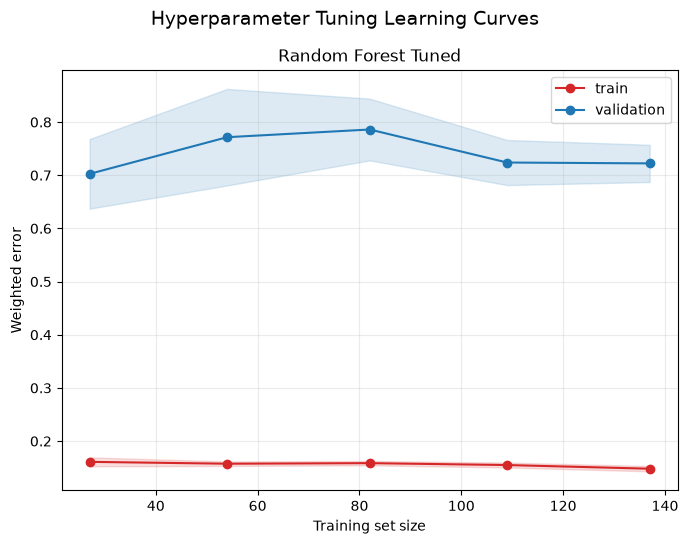

In [7]:
tuned_learning_curves = plot_learning_curves(
    tuned_estimators,
    "Hyperparameter Tuning Learning Curves",
)


## Hyperparameter Tuning Feature Importance

- **Purpose:** Apply the same estimator-aware MDI, MDA, and SFI methods to the final tuned family.
- **Settings:** `cv=5`; `pct_embargo=0.01`; `random_state=42`; `top_k=15`; MDA and SFI use weighted negative log loss.
- **Data:** Calculate and preserve tuned-model importance results for all 53 development features.
- **Decision:** Treat changes from baseline as diagnostics rather than feature selection.


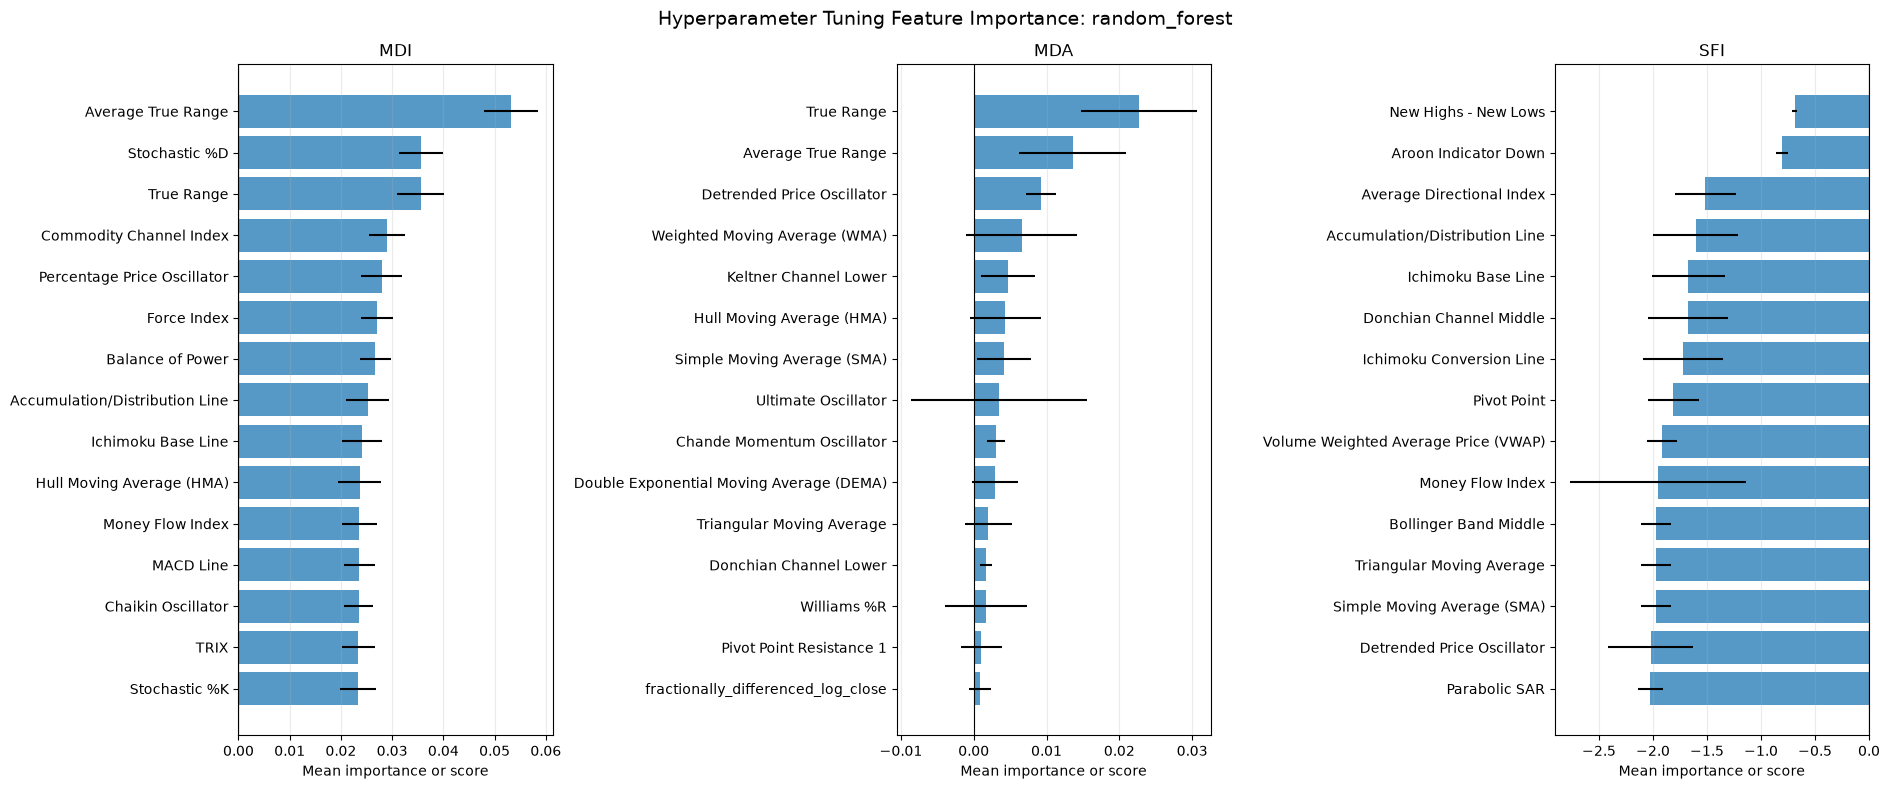

,mdi,mda,sfi_neg_log_loss
True Range,0.035580,0.022685,-2.496111
Average True Range,0.053195,0.013615,-2.986146
Detrended Price Oscillator,0.021575,0.009223,-2.020357
Weighted Moving Average (WMA),0.014477,0.006596,-2.232138
Keltner Channel Lower,0.012583,0.004726,-3.303509
Hull Moving Average (HMA),0.023668,0.004307,-2.421486
Simple Moving Average (SMA),0.017303,0.004201,-1.970535
Ultimate Oscillator,0.023250,0.003502,-3.886711
Chande Momentum Oscillator,0.017313,0.003052,-2.592718
Double Exponential Moving Average (DEMA),0.022422,0.002920,-2.212220


,oos_score
MDI,-0.72233
MDA,-0.72233
SFI,-0.72233


In [8]:
tuned_importance_results, tuned_importance_scores = compute_stage_importance(
    final_estimator
)
plot_feature_importance(
    tuned_importance_results,
    f"Hyperparameter Tuning Feature Importance: {final_name}",
)
importance = pd.DataFrame({
    "mdi": tuned_importance_results["MDI"]["mean"],
    "mda": tuned_importance_results["MDA"]["mean"],
    "sfi_neg_log_loss" if IMPORTANCE_SCORING == "neg_log_loss" else "sfi_f1": (
        tuned_importance_results["SFI"]["mean"]
    ),
}).sort_values("mda", ascending=False)
display(importance.head(15))
display(tuned_importance_scores.to_frame())


## Hyperparameter Tuning Model Evaluation

- **Purpose:** Compare the selected family's baseline and tuned accuracy, precision, recall, F1, log loss, and diagnostic curves before final evaluation.
- **Settings:** Metric order is accuracy, precision, recall, F1, then weighted log loss; confusion matrix, PR, and ROC remain weighted; `holdout_evaluations=1`.
- **Data:** Use development OOF results and one final holdout evaluation, then persist the model and prediction provenance.
- **Decision:** Fix the configuration from development OOF and evaluate holdout exactly once.


,accuracy,precision,recall,f1,log_loss
model,,,,,
Random Forest Baseline,0.579238,0.539755,0.587847,0.562775,0.718619
Random Forest Tuned,0.579238,0.539755,0.587847,0.562775,0.718619


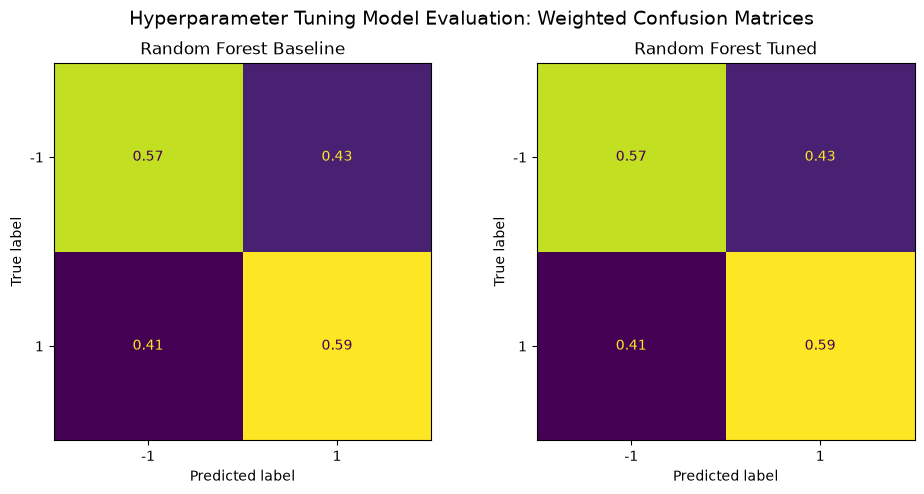

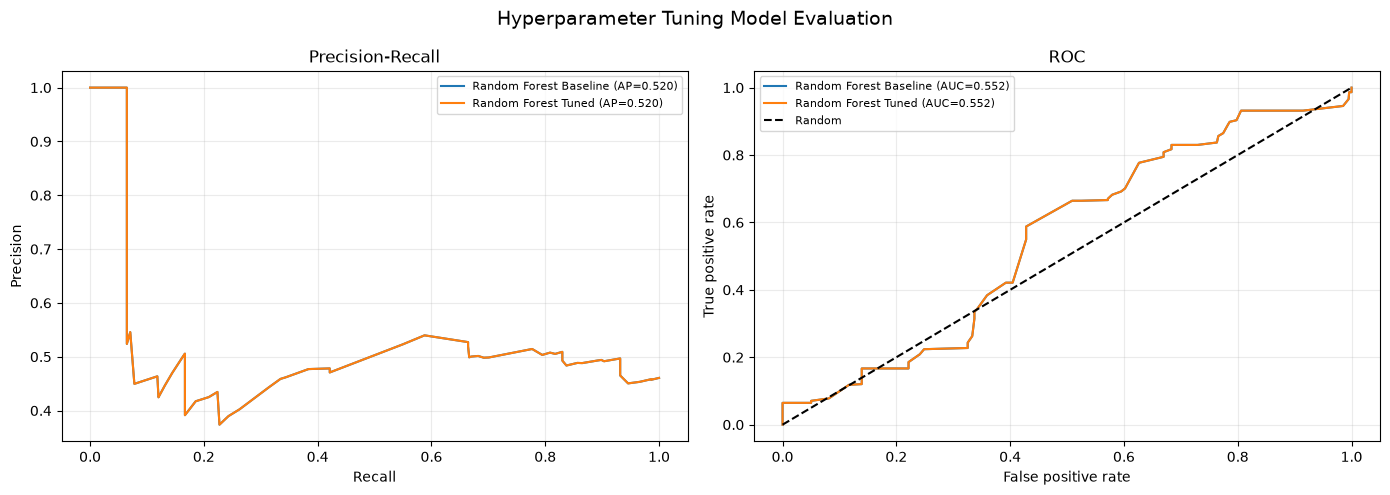

,holdout
accuracy,0.632825
precision,0.629975
recall,0.699692
f1,0.663006
log_loss,0.701776


,accuracy,precision,recall,f1,log_loss
model,,,,,
Final Holdout,0.632825,0.629975,0.699692,0.663006,0.701776


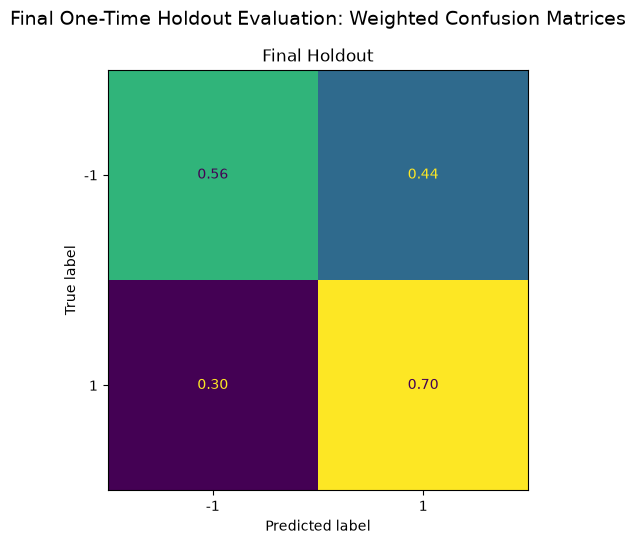

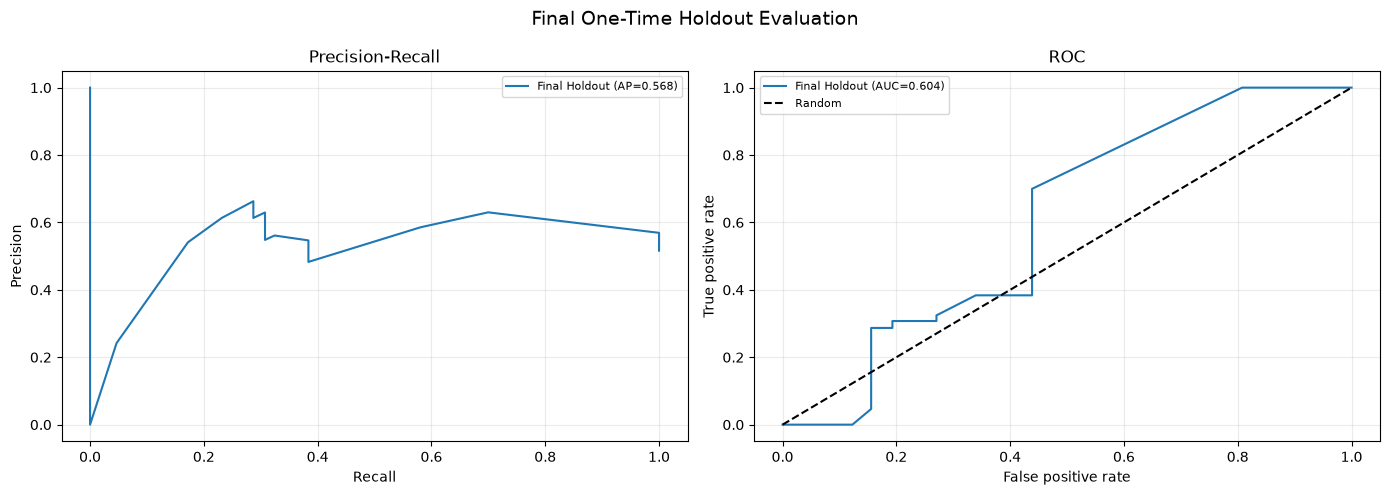

/Users/kwonjunhyuk9/Documents/financial-machine-learning/data/model_artifact/primary_model.joblib


In [9]:
tuning_evaluation_oof = {
    f"{selected_name}_baseline": candidate_oof[selected_name],
    f"{final_name}_tuned": final_oof,
}
plot_model_evaluation(
    tuning_evaluation_oof,
    y_development,
    w_development,
    "Hyperparameter Tuning Model Evaluation",
)

final_primary = clone(final_estimator).fit(
    X_development,
    y_development,
    sample_weight=w_development.to_numpy(),
)
holdout_probability = final_primary.predict_proba(
    holdout[feature_columns]
)[:, list(final_primary.classes_).index(1)]
holdout_side = final_primary.predict(holdout[feature_columns]).astype("int8")

primary_oof_output = development[[
    "event_end", "raw_return", "direction_label", "sample_weight"
]].copy()
primary_oof_output["partition"] = "development"
primary_oof_output["primary_side"] = final_oof["prediction"].astype("int8")
primary_oof_output["primary_probability"] = final_oof["probability"]
primary_oof_output["primary_probability_negative"] = 1.0 - final_oof["probability"]
primary_oof_output["primary_probability_positive"] = final_oof["probability"]
primary_oof_output["primary_class_probability"] = np.where(
    primary_oof_output["primary_side"].eq(1),
    primary_oof_output["primary_probability_positive"],
    primary_oof_output["primary_probability_negative"],
)
primary_oof_output["primary_confidence"] = np.maximum(
    final_oof["probability"],
    1.0 - final_oof["probability"],
)
primary_oof_output["prediction_source"] = final_oof["prediction_source"]
primary_oof_output["cv_fold"] = final_oof["fold"]

primary_holdout_output = holdout[[
    "event_end", "raw_return", "direction_label", "sample_weight"
]].copy()
primary_holdout_output["partition"] = "holdout"
primary_holdout_output["primary_side"] = holdout_side
primary_holdout_output["primary_probability"] = holdout_probability
primary_holdout_output["primary_probability_negative"] = 1.0 - holdout_probability
primary_holdout_output["primary_probability_positive"] = holdout_probability
primary_holdout_output["primary_class_probability"] = np.where(
    primary_holdout_output["primary_side"].eq(1),
    primary_holdout_output["primary_probability_positive"],
    primary_holdout_output["primary_probability_negative"],
)
primary_holdout_output["primary_confidence"] = np.maximum(
    holdout_probability,
    1.0 - holdout_probability,
)
primary_holdout_output["prediction_source"] = "holdout"
primary_holdout_output["cv_fold"] = pd.NA

holdout_prediction_frame = pd.DataFrame({
    "prediction": holdout_side,
    "probability": holdout_probability,
}, index=holdout.index)
holdout_scores = score_binary_predictions(
    holdout["direction_label"],
    holdout_prediction_frame["prediction"],
    holdout_prediction_frame["probability"],
    holdout["sample_weight"],
    class_labels=CLASS_LABELS,
    positive_label=1,
)
holdout_metrics = pd.Series({
    "accuracy": holdout_scores["accuracy"],
    "precision": holdout_scores["precision"],
    "recall": holdout_scores["recall"],
    "f1": holdout_scores["f1"],
    "log_loss": holdout_scores["log_loss"],
}, name="holdout")
display(holdout_metrics.to_frame())
plot_model_evaluation(
    {"final_holdout": holdout_prediction_frame},
    holdout["direction_label"],
    holdout["sample_weight"],
    "Final One-Time Holdout Evaluation",
)

primary_predictions = pd.concat([
    primary_oof_output,
    primary_holdout_output,
]).sort_index()
primary_predictions.to_parquet(artifact_dir / "primary_predictions.parquet")
joblib.dump({
    "estimator": final_primary,
    "feature_columns": feature_columns,
    "selected_candidate": final_name,
    "best_configuration": final_configuration,
    "holdout_boundary": holdout.index.min(),
    "random_state": RANDOM_STATE,
}, artifact_dir / "primary_model.joblib")

print(artifact_dir / "primary_model.joblib")
